# Terrain Vente - Marrakech (Antigravity v5)
Cleaning + Training XGBoost — cible R² > 0.70

##  Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../pipeline/ventes"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib
from datetime import datetime
from pathlib import Path
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from pip_terrain import (
    load_data, split_and_encode, build_pipeline,
    train, evaluate, plot_results, predict_price,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG,
    ZONE_MAP,
)

RAW_PATH   = Path("../../data/marrakech_immo_vente/terrain_vente.csv")
MODEL_PATH = Path("../../model_training/models/xgb_terrain_vente.pkl")
META_PATH  = Path("../../model_training/models/xgb_terrain_vente_metadata.json")
CLEAN_PATH = Path("../../data/cleaned_data/vente/terrain_vente_final.csv")
print("Imports OK")

Imports OK


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement et Cleaning

In [2]:
df = load_data(str(RAW_PATH))
print(f"\nShape finale : {df.shape}")
print(f"Colonnes     : {df.columns.tolist()}")


  Filtre terrain : 2593 / 3930 lignes
 Données chargées — 1424 lignes, 43 zones

Shape finale : (1424, 104)
Colonnes     : ['id', 'titre', 'prix', 'localisation', 'type_bien', 'surface', 'chambres', 'salles_bain', 'description', 'agence', 'url', 'source', 'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'etage', 'surface_terrain', 'prix_num', 'surface_num', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2', 'prix_m2_median_quartier', 'usage', 'titre_juridique', 'surface_terrain_m2', 'facade_ml', 'viabilise', 'eau', 'electricite', 'topographie', 'forme', 'prix_affiche_m2', 'type_vendeur', 'negociable', 'r_plus', 'orientation', 'proximite', 'nb_photos', 'date_publication', 'url_error', 'viabilise_eau', 'viabilise_electricite', 'r_plus_autorise', 'coordonnees_gps', 'prix_m2_scrapped', 'prix_m2_source', 'url_visited', 'etage_known', 'source_clean', 'is_particulier', 'usage_score', 'usage_cat

### 1.1 Coverage Antigravity

In [3]:
print("=== Coverage Antigravity (terrains) ===")
ag_cols = ["usage","titre_juridique","viabilise","eau","electricite",
           "r_plus","topographie","forme","negociable","nb_photos"]
for c in ag_cols:
    if c in df.columns:
        n = df[c].replace("", np.nan).notna().sum()
        print(f"  {c:20s}: {n}/{len(df)} ({n/len(df)*100:.0f}%)")

print("\n=== usage distribution ===")
print(df["usage_cat"].value_counts())
print("\n=== statut_titre distribution ===")
print(df["statut_titre"].value_counts())

=== Coverage Antigravity (terrains) ===
  usage               : 0/1424 (0%)
  titre_juridique     : 0/1424 (0%)
  viabilise           : 0/1424 (0%)
  eau                 : 0/1424 (0%)
  electricite         : 0/1424 (0%)
  r_plus              : 0/1424 (0%)
  topographie         : 0/1424 (0%)
  forme               : 0/1424 (0%)
  negociable          : 0/1424 (0%)
  nb_photos           : 0/1424 (0%)

=== usage distribution ===
usage_cat
non_precise    1424
Name: count, dtype: int64

=== statut_titre distribution ===
statut_titre
non_specifie     919
titre_foncier    436
melkiya           69
Name: count, dtype: int64


### 1.2 Distributions

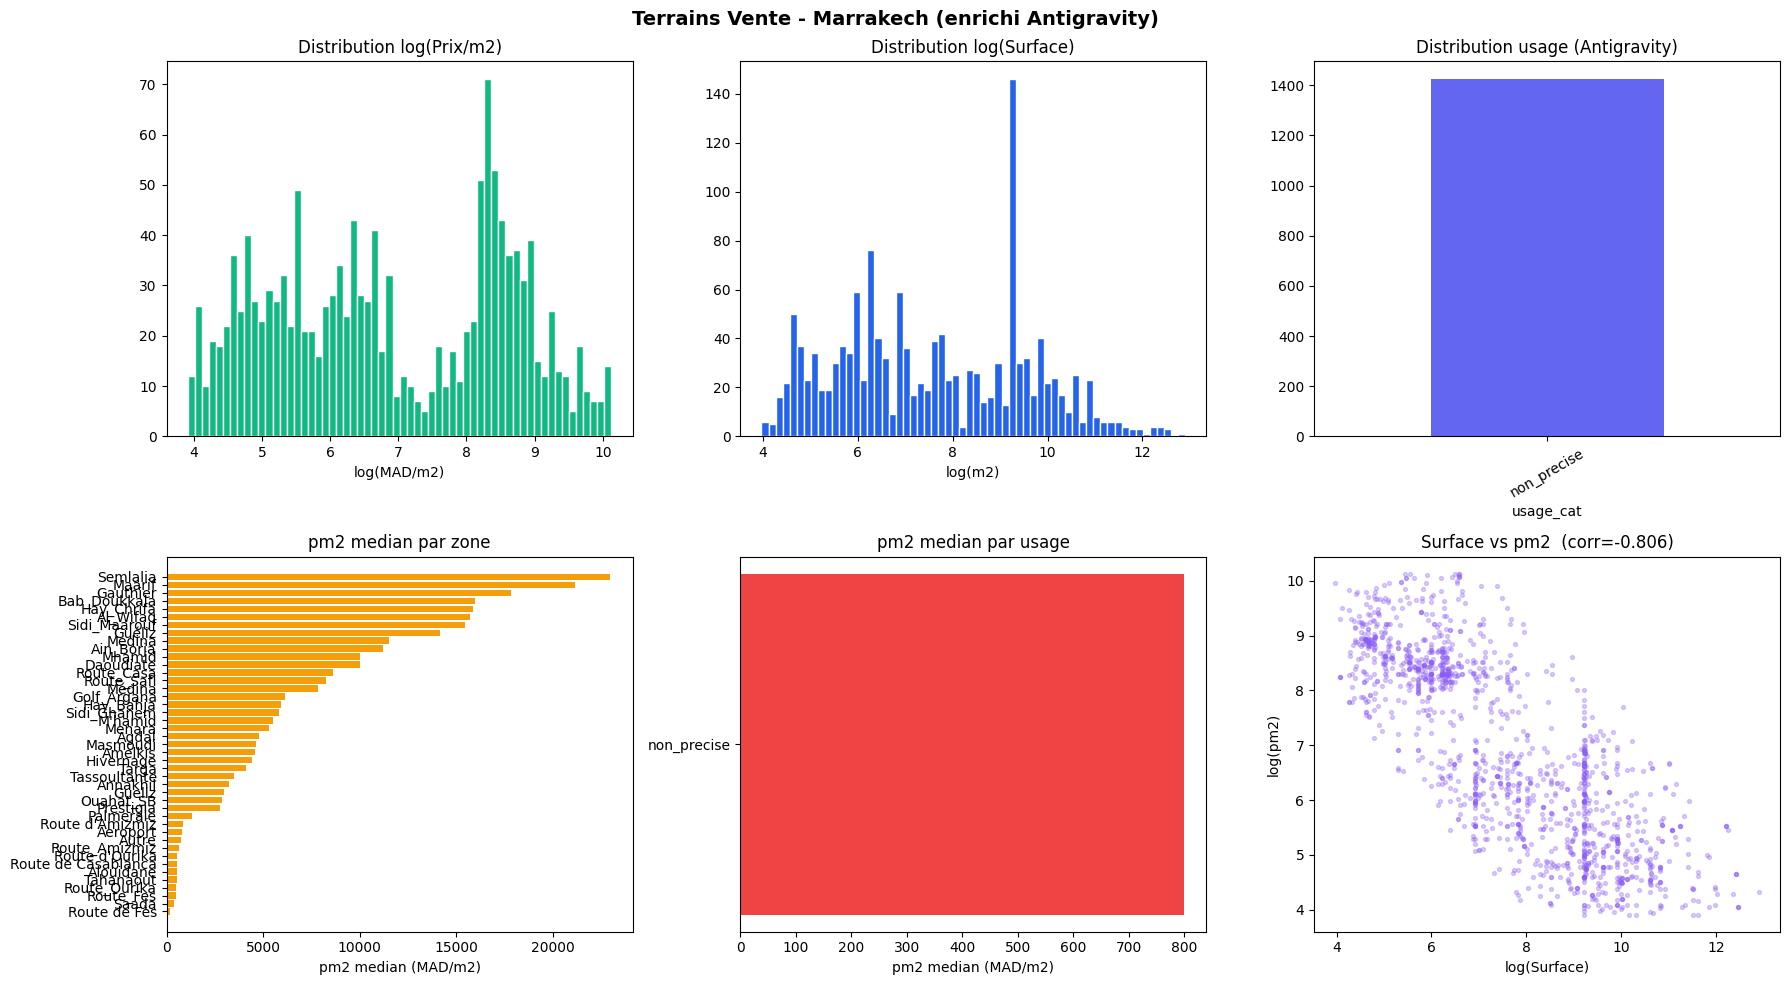

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Terrains Vente - Marrakech (enrichi Antigravity)", fontsize=14, fontweight="bold")

axes[0,0].hist(df["log_pm2"], bins=60, color="#10B981", edgecolor="white")
axes[0,0].set_title("Distribution log(Prix/m2)")
axes[0,0].set_xlabel("log(MAD/m2)")

axes[0,1].hist(df["log_surface"], bins=60, color="#2563EB", edgecolor="white")
axes[0,1].set_title("Distribution log(Surface)")
axes[0,1].set_xlabel("log(m2)")

df["usage_cat"].value_counts().plot(kind="bar", ax=axes[0,2], color="#6366F1")
axes[0,2].set_title("Distribution usage (Antigravity)")
axes[0,2].tick_params(axis="x", rotation=30)

med_zone = df.groupby("zone_clean")["pm2"].median().sort_values()
axes[1,0].barh(med_zone.index, med_zone.values, color="#F59E0B")
axes[1,0].set_xlabel("pm2 median (MAD/m2)")
axes[1,0].set_title("pm2 median par zone")

med_usage = df.groupby("usage_cat")["pm2"].median().sort_values()
axes[1,1].barh(med_usage.index, med_usage.values, color="#EF4444")
axes[1,1].set_xlabel("pm2 median (MAD/m2)")
axes[1,1].set_title("pm2 median par usage")

axes[1,2].scatter(df["log_surface"], df["log_pm2"], alpha=0.3, s=8, color="#8B5CF6")
axes[1,2].set_xlabel("log(Surface)")
axes[1,2].set_ylabel("log(pm2)")
axes[1,2].set_title(f"Surface vs pm2  (corr={df['log_surface'].corr(df['log_pm2']):.3f})")

plt.tight_layout()
plt.show()

### 1.3 Stats par zone et usage

In [5]:
print("=== pm2 median par usage (Antigravity) ===")
print(df.groupby("usage_cat")["pm2"]
      .agg(["median","std","count"]).sort_values("median", ascending=False).round(0))

print("\n=== pm2 median par zone ===")
print(df.groupby("zone_clean")["pm2"]
      .agg(["median","std","count"]).sort_values("median", ascending=False).round(0))

print("\n=== Variance log_pm2 par zone ===")
print(df.groupby("zone_clean")["log_pm2"]
      .agg(["std","count"]).sort_values("std", ascending=False).round(3))

=== pm2 median par usage (Antigravity) ===
             median     std  count
usage_cat                         
non_precise   800.0  4453.0   1424

=== pm2 median par zone ===
                      median     std  count
zone_clean                                 
Semlalia             23000.0  3768.0      9
Maarif               21154.0     NaN      1
Gauthier             17861.0  1610.0      2
Bab_Doukkala         16002.0  1596.0      3
Hay_Chrifa           15882.0    12.0      2
Al_Wifaq             15702.0     NaN      1
Sidi_Maarouf         15453.0   369.0      2
Guéliz               14167.0  7640.0     16
Medina               11538.0  7182.0      5
Ain_Borja            11226.0  1076.0      2
Daoudiate            10000.0     NaN      1
Mhamid               10000.0  5117.0     10
Route_Casa            8633.0  6593.0     21
Route_Safi            8250.0  8391.0     14
Médina                7857.0  6739.0     12
Golf_Argana           6156.0  1936.0      4
Hay_Bahja             5940.0   

### 1.4 Correlations

In [6]:
print("=== Correlations avec log_pm2 ===")
num_check = ["log_surface","log_surface_sq","usage_score","r_plus_num",
             "is_titre_foncier","is_melkiya","is_viabilise","has_eau",
             "is_plat","is_angle","is_negociable","nb_photos_clean",
             "km_distance","terrain_quality"]
avail = [c for c in num_check if c in df.columns]
print(df[avail + ["log_pm2"]].corr()["log_pm2"].drop("log_pm2")
      .sort_values(ascending=False).round(3))

=== Correlations avec log_pm2 ===
terrain_quality     0.398
r_plus_num          0.178
is_angle            0.160
is_viabilise        0.066
is_plat            -0.032
is_titre_foncier   -0.073
is_melkiya         -0.095
km_distance        -0.148
has_eau            -0.222
log_surface_sq     -0.790
log_surface        -0.806
usage_score           NaN
is_negociable         NaN
nb_photos_clean       NaN
Name: log_pm2, dtype: float64


## 2. Split et Feature Engineering

In [7]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"\nFeatures total : {len(NUMERIC_FEATURES+BINARY_FEATURES+CATEGORICAL_FEATURES)}")
print(f"  NUMERIC  : {len(NUMERIC_FEATURES)}")
print(f"  BINARY   : {len(BINARY_FEATURES)}")
print(f"  CATEG    : {len(CATEGORICAL_FEATURES)} -> {CATEGORICAL_FEATURES}")
print(f"  Target   : {TARGET_LOG}")
print(f"  X_train  : {X_train.shape}")

 Split — Train : 1139 | Test : 285 | Features : 69

Features total : 69
  NUMERIC  : 42
  BINARY   : 22
  CATEG    : 5 -> ['zone_clean', 'source_clean', 'usage_cat', 'statut_titre', 'surface_cat']
  Target   : log_pm2
  X_train  : (1139, 69)


## 3. Baseline

In [8]:
pipeline_baseline = build_pipeline(X_train)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, df_test,
                              X_train=X_train, y_train=y_train)

 Pipeline — num:42 bin:22 cat:5
 Entraînement terminé (cible = log pm²)

════════════════════════════════════════════════════
  MÉTRIQUES D'ÉVALUATION — TERRAIN v5
════════════════════════════════════════════════════
   Sur log(pm²)  [comparable au CV] 
  R² (log pm²)     :          0.8122
  MAPE (log pm²)   :          8.88 %
  CV R² (5 folds)  : 0.8056 ± 0.0271
   Sur prix bruts MAD  [business] 
  MAE              :       2,139,961 MAD
  RMSE             :       5,285,664 MAD
  R² (prix MAD)    :          0.2644  ← amplifié par exp()
  MAPE (prix MAD)  :         67.68 %  ← amplifié par exp()
════════════════════════════════════════════════════


### 3.1 Diagnostic baseline

In [9]:
log_pm2_pred = pipeline_baseline.predict(X_test)
prix_pred    = np.exp(log_pm2_pred) * df_test["surface_num"].values
prix_reel    = df_test["prix_num"].values
erreur_pct   = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_err = X_test.copy()
df_err["erreur_pct"] = erreur_pct

print("=== MAPE par zone (baseline) ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par usage (baseline) ===")
print(df_err.groupby("usage_cat")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

=== MAPE par zone (baseline) ===
                      mean  count
zone_clean                       
Hivernage            399.0      1
Route_Ourika         220.9      5
Guéliz               157.6      4
Aeroport             146.2      4
Saada                144.0      1
M'hamid              128.1      1
Route de Casablanca  120.7     22
Daoudiate             92.0      1
Tahanaout             83.8     16
Route_Safi            78.5      4
Gueliz                78.3      2
Route_Casa            75.4      6
Route_Fes             69.7     14
Route de Fès          65.7     27
Prestigia             60.4     11
Autre                 59.0     57
Palmeraie             55.0      5
Route_Amizmiz         53.4     15
Al_Wifaq              52.2      1
Route d'Ourika        50.7     40
Mhamid                48.3      4
Medina                46.1      2
Annakhil              40.8      2
Menara                40.3      2
Gauthier              31.9      1
Amelkis               30.7      2
Bab_Doukkala   

## 4. Tuning Optuna (150 trials)

In [10]:
def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 500, 4000),
        max_depth         = trial.suggest_int("max_depth", 3, 7),
        learning_rate     = trial.suggest_float("learning_rate", 0.003, 0.1, log=True),
        max_leaves        = trial.suggest_int("max_leaves", 10, 63),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 2, 15),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-5, 2.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        gamma             = trial.suggest_float("gamma", 1e-5, 0.5, log=True),
        tree_method="hist", random_state=42, n_jobs=-1,
    )
    pipe = build_pipeline(X_train, params)
    kf   = KFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\nMeilleur R2 CV : {study.best_value:.4f}")
best_params = study.best_params
for k, v in best_params.items():
    print(f"  {k:25s}: {v}")

  0%|          | 0/150 [00:00<?, ?it/s]

 Pipeline — num:42 bin:22 cat:5


Best trial: 0. Best value: 0.773085:   1%|          | 1/150 [00:05<12:57,  5.22s/it]

 Pipeline — num:42 bin:22 cat:5


Best trial: 1. Best value: 0.806463:   1%|▏         | 2/150 [00:08<09:51,  3.99s/it]

...

 Pipeline — num:42 bin:22 cat:5


Best trial: 130. Best value: 0.809302:  99%|█████████▉| 149/150 [05:43<00:02,  2.27s/it]

 Pipeline — num:42 bin:22 cat:5


Best trial: 130. Best value: 0.809302: 100%|██████████| 150/150 [05:44<00:00,  2.30s/it]


Meilleur R2 CV : 0.8093
  n_estimators             : 3670
  max_depth                : 5
  learning_rate            : 0.005738494375615973
  max_leaves               : 53
  subsample                : 0.9637925583752829
  colsample_bytree         : 0.7629061467051441
  colsample_bylevel        : 0.589418908721689
  min_child_weight         : 8
  reg_alpha                : 1.3758201464104628e-05
  reg_lambda               : 0.1589024868374423
  gamma                    : 0.21357788820607926


## 5. Modele final

In [11]:
pipeline_final = build_pipeline(X_train, best_params)
pipeline_final = train(pipeline_final, X_train, y_train)
metrics_final  = evaluate(pipeline_final, X_test, y_test, df_test,
                           X_train=X_train, y_train=y_train)

r2_b = metrics_baseline["R2"]
r2_f = metrics_final["R2"]
mp_b = metrics_baseline["MAPE (%)"]
mp_f = metrics_final["MAPE (%)"]
print(f"\n=== Gain vs baseline ===")
print(f"  R2   : {r2_b:.4f} -> {r2_f:.4f}  ({r2_f - r2_b:+.4f})")
print(f"  MAPE : {mp_b:.2f}% -> {mp_f:.2f}%")

 Pipeline — num:42 bin:22 cat:5
 Entraînement terminé (cible = log pm²)

════════════════════════════════════════════════════
  MÉTRIQUES D'ÉVALUATION — TERRAIN v5
════════════════════════════════════════════════════
   Sur log(pm²)  [comparable au CV] 
  R² (log pm²)     :          0.8056
  MAPE (log pm²)   :          8.97 %
  CV R² (5 folds)  : 0.8093 ± 0.0274
   Sur prix bruts MAD  [business] 
  MAE              :       2,192,288 MAD
  RMSE             :       5,342,387 MAD
  R² (prix MAD)    :          0.2485  ← amplifié par exp()
  MAPE (prix MAD)  :         69.22 %  ← amplifié par exp()
════════════════════════════════════════════════════

=== Gain vs baseline ===
  R2   : 0.8122 -> 0.8056  (-0.0065)
  MAPE : 8.88% -> 8.97%


### 5.1 Analyse erreurs

In [12]:
log_pm2_pred = pipeline_final.predict(X_test)
prix_pred    = np.exp(log_pm2_pred) * df_test["surface_num"].values
prix_reel    = df_test["prix_num"].values
erreur_pct   = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_err = X_test.copy()
df_err["erreur_pct"] = erreur_pct
df_err["prix_reel"]  = prix_reel
df_err["prix_pred"]  = prix_pred
df_err["surface"]    = df_test["surface_num"].values

print("=== MAPE par zone ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par usage ===")
print(df_err.groupby("usage_cat")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== Precision par seuil ===")
for seuil in [20, 30, 40, 50]:
    pct = (erreur_pct <= seuil).mean() * 100
    print(f"  Erreur <= {seuil}% : {pct:.1f}% des cas")

print("\n=== Top 10 pires predictions ===")
print(df_err.nlargest(10, "erreur_pct")[
    ["surface","zone_clean","usage_cat","prix_reel","prix_pred","erreur_pct"]
].to_string())

=== MAPE par zone ===
                      mean  count
zone_clean                       
Hivernage            362.9      1
Route_Ourika         262.5      5
Guéliz               174.9      4
Route de Casablanca  129.9     22
M'hamid              129.5      1
Aeroport             119.2      4
Saada                108.5      1
Daoudiate             93.8      1
Tahanaout             86.4     16
Gueliz                84.8      2
Route_Casa            78.6      6
Route_Safi            76.4      4
Route_Fes             71.5     14
Route de Fès          65.6     27
Palmeraie             65.4      5
Autre                 60.3     57
Mhamid                58.1      4
Prestigia             57.6     11
Medina                57.3      2
Al_Wifaq              53.7      1
Route_Amizmiz         50.8     15
Tassoultante          50.6      1
Route d'Ourika        47.5     40
Menara                46.6      2
Annakhil              37.5      2
Route d'Amizmiz       34.8      8
Bab_Doukkala          30.3

## 6. Graphiques

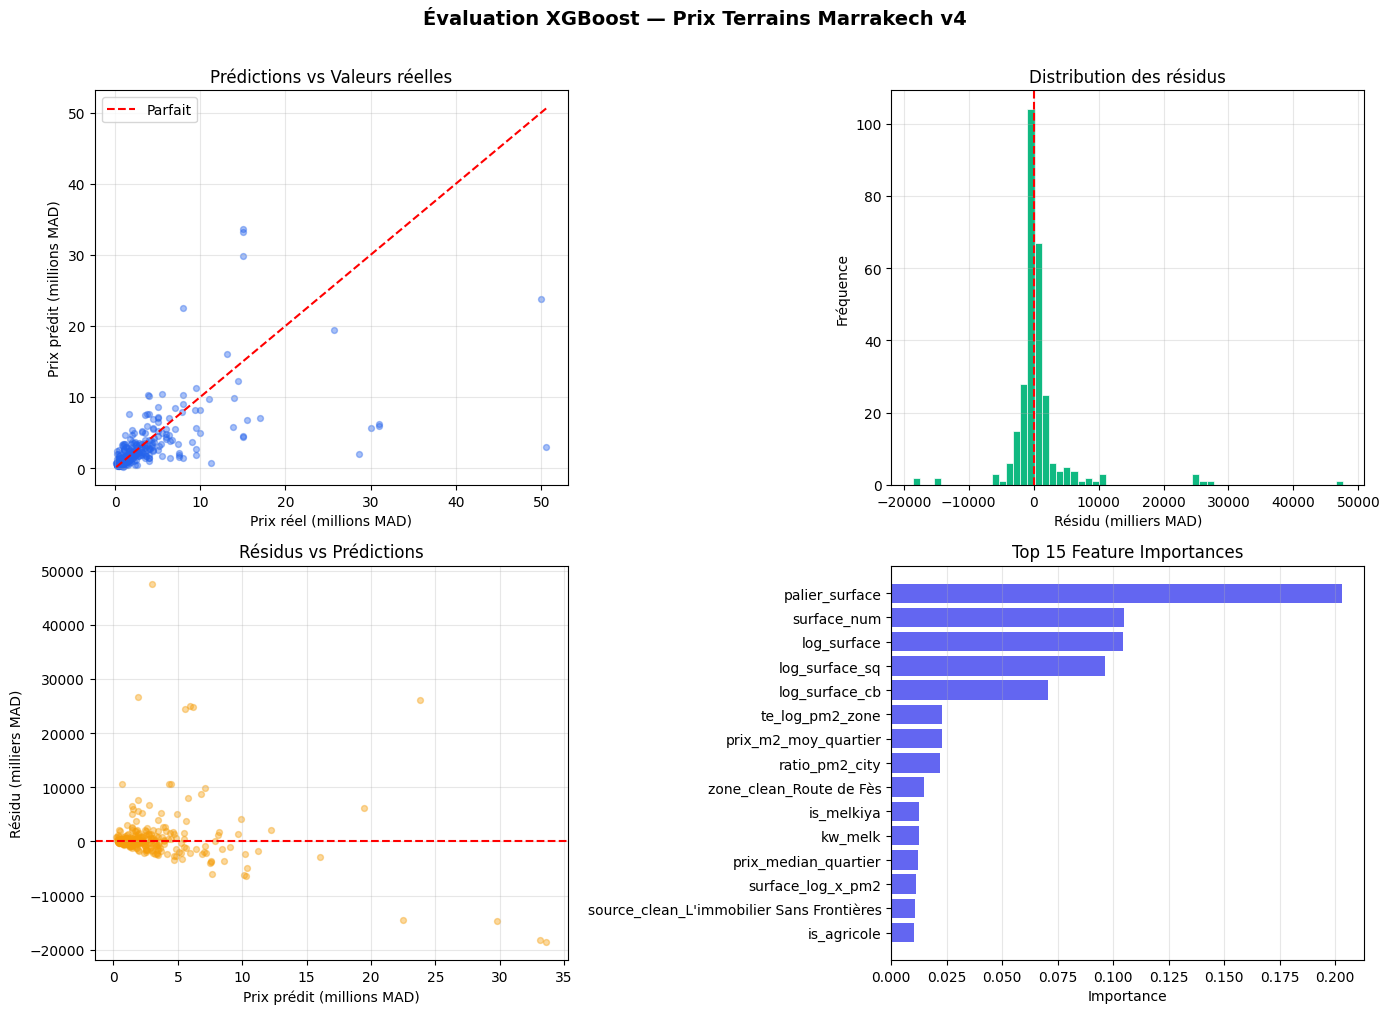

✅ Graphiques sauvegardés → terrain_model_evaluation.png


In [13]:
plot_results(pipeline_final, X_test, df_test)

### 6.1 Importances features

In [14]:
xgb_model = pipeline_final.named_steps["model"]
preproc   = pipeline_final.named_steps["preprocessor"]
try:
    num_bin = list(preproc.transformers_[0][2]) + list(preproc.transformers_[1][2])
    cat_enc = list(preproc.transformers_[2][1].get_feature_names_out(
                   preproc.transformers_[2][2]))
    feat_names = num_bin + cat_enc
except Exception as e:
    feat_names = [f"f{i}" for i in range(xgb_model.n_features_in_)]

imp = pd.Series(xgb_model.feature_importances_, index=feat_names)
print("=== Top 20 importances ===")
print(imp.sort_values(ascending=False).head(20).round(4))

# Verifier que les features Antigravity contribuent
ag_feats = ["usage_score","is_titre_foncier","is_melkiya","is_plat",
            "is_angle","is_viabilise","has_eau","r_plus_num",
            "surface_x_te","usage_x_te","zone_bias"]
print("\n=== Importance features Antigravity ===")
for f in ag_feats:
    val = imp.get(f, 0)
    print(f"  {f:25s}: {val:.4f}")

=== Top 20 importances ===
palier_surface                               0.2030
surface_num                                  0.1050
log_surface                                  0.1046
log_surface_sq                               0.0963
log_surface_cb                               0.0707
te_log_pm2_zone                              0.0230
prix_m2_moy_quartier                         0.0229
ratio_pm2_city                               0.0218
zone_clean_Route de Fès                      0.0150
is_melkiya                                   0.0127
kw_melk                                      0.0124
prix_median_quartier                         0.0123
surface_log_x_pm2                            0.0113
source_clean_L'immobilier Sans Frontières    0.0107
is_agricole                                  0.0104
surface_x_te                                 0.0095
terrain_quality                              0.0090
source_clean_avito                           0.0089
prix_estime                          

## 7. Sauvegarde

In [15]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f"Modele sauvegarde -> {MODEL_PATH}")

r2_val   = round(float(metrics_final["R2"]), 4)
mape_val = round(float(metrics_final["MAPE (%)"]), 2)
mae_val  = round(float(metrics_final["MAE (MAD)"]), 0)
rmse_val = round(float(metrics_final["RMSE (MAD)"]), 0)
r2_base  = round(float(metrics_baseline["R2"]), 4)
mb_mape  = round(float(metrics_baseline["MAPE (%)"]), 2)

metadata = {
    "date"             : datetime.now().strftime("%Y-%m-%d"),
    "version"          : "v5_antigravity_optuna",
    "modele"           : "XGBRegressor",
    "type_bien"        : "terrain_vente",
    "target"           : "log(pm2) -> prix = exp(pred) x surface",
    "n_lignes_train"   : len(X_train),
    "n_lignes_test"    : len(X_test),
    "n_features"       : X_train.shape[1],
    "n_zones"          : int(df["zone_clean"].nunique()),
    "ag_coverage_usage": int((df["usage_cat"] != "non_precise").sum()),
    "metriques_baseline": {"R2": r2_base, "MAPE": mb_mape},
    "metriques_test"   : {"R2": r2_val, "MAE": mae_val, "RMSE": rmse_val, "MAPE": mape_val},
    "cv_r2_optuna"     : round(study.best_value, 4),
    "hyperparametres"  : study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"Metadonnees -> {META_PATH}")

df.to_csv(CLEAN_PATH, index=False)
print(f"Dataset -> {CLEAN_PATH}")

print("\n" + "="*58)
print("  RESUME FINAL - TERRAIN VENTE v5 (Antigravity)")
print("="*58)
print(f"  Donnees   : {len(df):,} terrains | {df['zone_clean'].nunique()} zones")
print(f"  Usage enrichi : {(df['usage_cat'] != 'non_precise').sum()} terrains")
print(f"  Features  : {X_train.shape[1]}")
print(f"  R2 final  : {r2_val}")
print(f"  MAPE      : {mape_val} %")
print(f"  CV R2     : {study.best_value:.4f}")
print("="*58)

Modele sauvegarde -> ../../model_training/models/xgb_terrain_vente.pkl
Metadonnees -> ../../model_training/models/xgb_terrain_vente_metadata.json
Dataset -> ../../data/cleaned_data/vente/terrain_vente_final.csv

  RESUME FINAL - TERRAIN VENTE v5 (Antigravity)
  Donnees   : 1,424 terrains | 43 zones
  Usage enrichi : 0 terrains
  Features  : 69
  R2 final  : 0.8056
  MAPE      : 8.97 %
  CV R2     : 0.8093


## 8. Predictions unitaires

In [16]:
saved           = joblib.load(MODEL_PATH)
pipeline_loaded = saved["pipeline"]
stats_loaded    = saved["stats"]

# Exemple 1 : Terrain immeuble R+3 Gueliz
terrain1 = {
    "surface_num"     : 400,
    "zone_clean"      : "Gueliz",
    "usage"           : "immeuble_r3",
    "titre_juridique" : "titre_foncier",
    "r_plus"          : "R+3",
    "topographie"     : "plat",
    "forme"           : "angle",
    "source_clean"    : "avito",
}
print("=== Exemple 1 : Immeuble R+3 Gueliz 400m2 ===")
r1 = predict_price(pipeline_loaded, terrain1, stats_loaded)

# Exemple 2 : Terrain agricole Route Ourika
terrain2 = {
    "surface_num"     : 8000,
    "zone_clean"      : "Route_Ourika",
    "usage"           : "agricole",
    "titre_juridique" : "melkiya",
    "source_clean"    : "avito",
}
print("\n=== Exemple 2 : Agricole Route Ourika 8000m2 ===")
r2 = predict_price(pipeline_loaded, terrain2, stats_loaded)

# Exemple 3 : Terrain villa Palmeraie
terrain3 = {
    "surface_num"     : 1500,
    "zone_clean"      : "Palmeraie",
    "usage"           : "villa",
    "titre_juridique" : "titre_foncier",
    "viabilise"       : True,
    "source_clean"    : "avito",
}
print("\n=== Exemple 3 : Villa Palmeraie 1500m2 ===")
r3 = predict_price(pipeline_loaded, terrain3, stats_loaded)

# Tableau comparatif
print("\n=== Tableau comparatif ===")
rows = [
    ("Immeuble R+3 Gueliz 400m2",  r1["prix_estime"], r1["pm2"]),
    ("Agricole Route Ourika 8000m2",r2["prix_estime"], r2["pm2"]),
    ("Villa Palmeraie 1500m2",      r3["prix_estime"], r3["pm2"]),
]
for label, prix, pm2 in rows:
    print(f"  {label:35s}: {prix:>12,.0f} MAD  ({pm2:>6,.0f} MAD/m2)")

=== Exemple 1 : Immeuble R+3 Gueliz 400m2 ===
  Terrain  : 400 m²  |  Zone : Gueliz
 Prix estimé : 2,624,600 MAD  (243,019 EUR)
   Prix/m²    : 6,562 MAD/m²

=== Exemple 2 : Agricole Route Ourika 8000m2 ===
  Terrain  : 8000 m²  |  Zone : Route_Ourika
 Prix estimé : 951,193 MAD  (88,073 EUR)
   Prix/m²    : 119 MAD/m²

=== Exemple 3 : Villa Palmeraie 1500m2 ===
  Terrain  : 1500 m²  |  Zone : Palmeraie
 Prix estimé : 1,447,829 MAD  (134,058 EUR)
   Prix/m²    : 965 MAD/m²

=== Tableau comparatif ===
  Immeuble R+3 Gueliz 400m2          :    2,624,600 MAD  ( 6,562 MAD/m2)
  Agricole Route Ourika 8000m2       :      951,193 MAD  (   119 MAD/m2)
  Villa Palmeraie 1500m2             :    1,447,829 MAD  (   965 MAD/m2)
